<a href="https://colab.research.google.com/github/Kunj-7007/AI_ML_Workshop_LDRP/blob/Day3/ML_SVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

In [ ]:
#Load the dataset
data=pd.read_csv('/content/waste management.csv')
#display first few rows
print (data.head())
print(data.shape)

   waste_type  material_composition  recycling_potential  toxicity_level  \
0           3              0.198716             0.016588       81.011339   
1           1              0.005522             0.512093       86.707232   
2           3              0.815461             0.226496       91.324055   
3           3              0.706857             0.645173       51.134240   
4           1              0.729007             0.174366       50.151629   

   management_strategy  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  
(100, 5)


In [ ]:
#Define features and target variable
x=data[['waste_type','material_composition','recycling_potential','toxicity_level']]
y=data['management_strategy']  #1 for effective reduction , 0 otherwis

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [ ]:
model=SVC(kernel='rbf',C=1,gamma='auto')
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [ ]:
y_pred


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
#Accurracy
accuracy_score=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy_score}")

Accuracy: 0.9


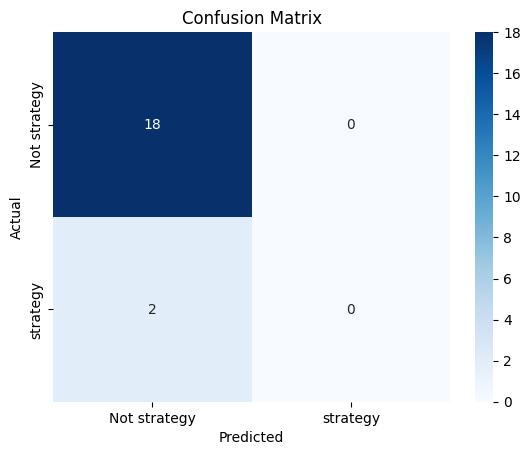

In [ ]:
#Confusion matirx
conf_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Not strategy','strategy'],
            yticklabels=['Not strategy','strategy']
            )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Classification report
print (classification_report(y_test,y_pred , target_names=['Not strategy','strategy']))

              precision    recall  f1-score   support

Not strategy       0.90      1.00      0.95        18
    strategy       0.00      0.00      0.00         2

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


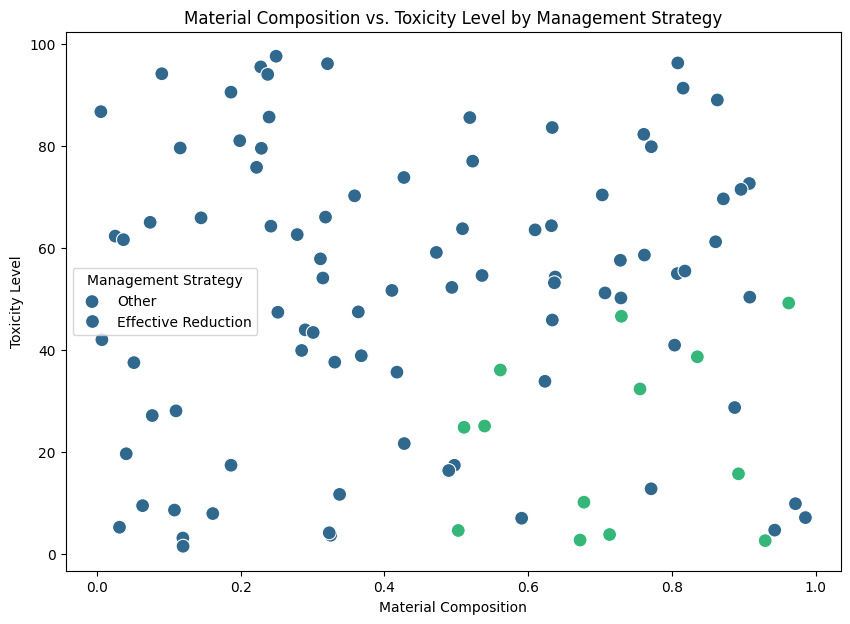

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='material_composition', y='toxicity_level', hue='management_strategy', data=data, palette='viridis', s=100)
plt.title('Material Composition vs. Toxicity Level by Management Strategy')
plt.xlabel('Material Composition')
plt.ylabel('Toxicity Level')
plt.legend(title='Management Strategy', labels=['Other', 'Effective Reduction'])
plt.show()